# T70 — Trait-based extinction selectivity in the K-Pg plankton collapse (EcoGEM)

**Cluster J: Paleoclimate.**  *Dataset:* cGENIE-EcoGEM K-Pg boundary experiments (Ying et al. 2026, CC BY 4.0) — 112 plankton functional types (PFTs) spanning phytoplankton, zooplankton, mixotrophs, and two foraminifera guilds, each with an explicit cell size and trophic strategy.

T69 showed the K-Pg impact winter as a global biogeochemical shock — an ocean-wide collapse in temperature, pH, and export production. But mass extinctions are famously *selective*: not every organism dies at the same rate, and which traits predict survival is one of the central questions in extinction biology. cGENIE's EcoGEM module resolves the plankton community as 112 distinct functional types, each defined by a cell diameter spanning close to five orders of magnitude (0.1 to 2,800 μm) and a trophic strategy (phytoplankton, zooplankton, mixotroph, or one of two foraminifera guilds) — enough resolution to ask, directly from the model, *does body size predict who collapses and who survives?*

## What this notebook produces

1. **§2 — The plankton trait space.** The 112 PFTs' cell diameter and trophic-strategy composition — what community structure looked like before the size-selectivity question can even be asked.
2. **§3 — Size-selective collapse.** Per-PFT biomass change (baseline vs. end-of-crisis) plotted against cell diameter, on a log axis, coloured by trophic strategy — the core result.
3. **§4 — Does the export-size link explain the pattern?** Compares the standard `main` run against `size_effect` (same extinction mechanism, but with the size-dependent particulate/dissolved organic carbon export ratio switched off) to test how much of the size-selectivity is driven by that specific mechanism versus other model processes.
4. **§5 — Spatial reorganisation of the plankton size structure.** Global maps of biomass-weighted mean cell size, before and after the crisis, on cGENIE's own paleogeography with a `gplately`-reconstructed 66 Ma continent overlay for context.

## Learning objectives

- Work with a large functional-type ensemble (112 PFTs) as a tidy trait table joined against per-type model output.
- Build a log-size-axis scatter/selectivity plot — a standard tool in body-size macroecology and extinction biology.
- Use a single-mechanism sensitivity experiment (`size_effect`) to test whether a specific modelled process is responsible for an emergent pattern.
- Render a derived ecosystem-structure field (biomass-weighted mean cell size) as a `pygmt` map, reusing the K-Pg paleogeography rendering pattern from T69, including its reconstructed-continent overlay convention.

## Prerequisites and runtime

- **Plate model**: Scotese & Wright (2018) — the same paleogeography cGENIE's own K-Pg boundary condition is built on (§5 map-context overlay only; see T69 §3 for why this model, not an independent one, is used here).
- **Data (bundled, git-tracked)**: `data/cgenie_kpg_ying2026/` (1.1 MB) — same compact cGENIE K-Pg bundle as T69 (Ying et al. 2026, CC BY 4.0); this notebook uses `kpg_pft_traits.csv`, `kpg_pft_biomass_baseline_vs_post.csv`, and `kpg_ecogem_size_maps.nc`. See `data/cgenie_kpg_ying2026/README.md`.
- **Python**: `gplately`, `pygmt`, `pygplates`, `xarray`, `numpy`, `pandas`.
- **Runtime**: ~20 s.


## Environment + imports

In [1]:
from pathlib import Path
import os, sys
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import xarray as xr
import pygmt
import gplately
import pygplates
from plate_model_manager import PlateModelManager

sys.path.insert(0, str(Path("Notebooks").resolve()))
from paleoclimate_helpers import refine_for_plot

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, xr, pygmt, gplately, pygplates):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', getattr(_m, 'version', 'n/a'))}")


Environment
  python      3.11.15
  numpy       2.4.4
  pandas      3.0.2
  xarray      2026.7.0
  pygmt       v0.17.0
  gplately    2.0.0
  pygplates   1.0.0


## Configuration

In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME    = "scotese_and_wright2018"  # the plate model cGENIE's own K-Pg paleogeography is built on
RECON_AGE_MA  = 66.0

DATA_DIR       = Path("data/cgenie_kpg_ying2026")
TRAITS_CSV     = DATA_DIR / "kpg_pft_traits.csv"
BIOMASS_CSV    = DATA_DIR / "kpg_pft_biomass_baseline_vs_post.csv"
SIZE_MAPS_NC   = DATA_DIR / "kpg_ecogem_size_maps.nc"

TYPE_COLOURS = {
    "phytoplankton": "seagreen",
    "zooplankton":   "steelblue",
    "mixotroph":      "darkorange",
    "foram_bn":       "firebrick",
    "foram_sn":       "purple",
}

REGION = "d"
PROJ   = "N16c"

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


## 1. Load the PFT trait table + biomass summary

In [3]:
traits = pd.read_csv(TRAITS_CSV)
biomass = pd.read_csv(BIOMASS_CSV)

print(f"  {len(traits)} plankton functional types (PFTs)")
print(traits['PFT'].value_counts().to_string())
print(f"\n  diameter range: {traits['diameter'].min():.2f}-{traits['diameter'].max():.0f} \u03bcm")
print(f"  biomass summary: {biomass['experiment'].unique().tolist()} x {biomass['stage'].unique().tolist()}")


  112 plankton functional types (PFTs)
PFT
phytoplankton    32
zooplankton      32
mixotroph        32
foram_bn          8
foram_sn          8

  diameter range: 0.10-2800 μm
  biomass summary: ['main', 'size_effect'] x ['baseline', 'post_impact']


## 2. The plankton trait space

Cell diameter spans close to five orders of magnitude — from 0.1 μm picophytoplankton to a 2,800 μm giant zooplankton PFT (the largest single PFT in the whole ensemble; the largest *foraminifera* PFT tops out at 874 μm). Two dedicated foraminifera guilds (`foram_bn` — non-symbiotic, 40-330 μm; `foram_sn` — symbiont-bearing, 100-874 μm) sit toward the large end of the size spectrum without being its extreme: real planktic foraminifera have one of the best marine microfossil records of any group, which is what makes the K-Pg selectivity question testable against real data (see T71). The two guilds' 8+8 = 16 PFTs match the total foraminifera count Ying et al. (2026) report for their trait-based ecosystem model.

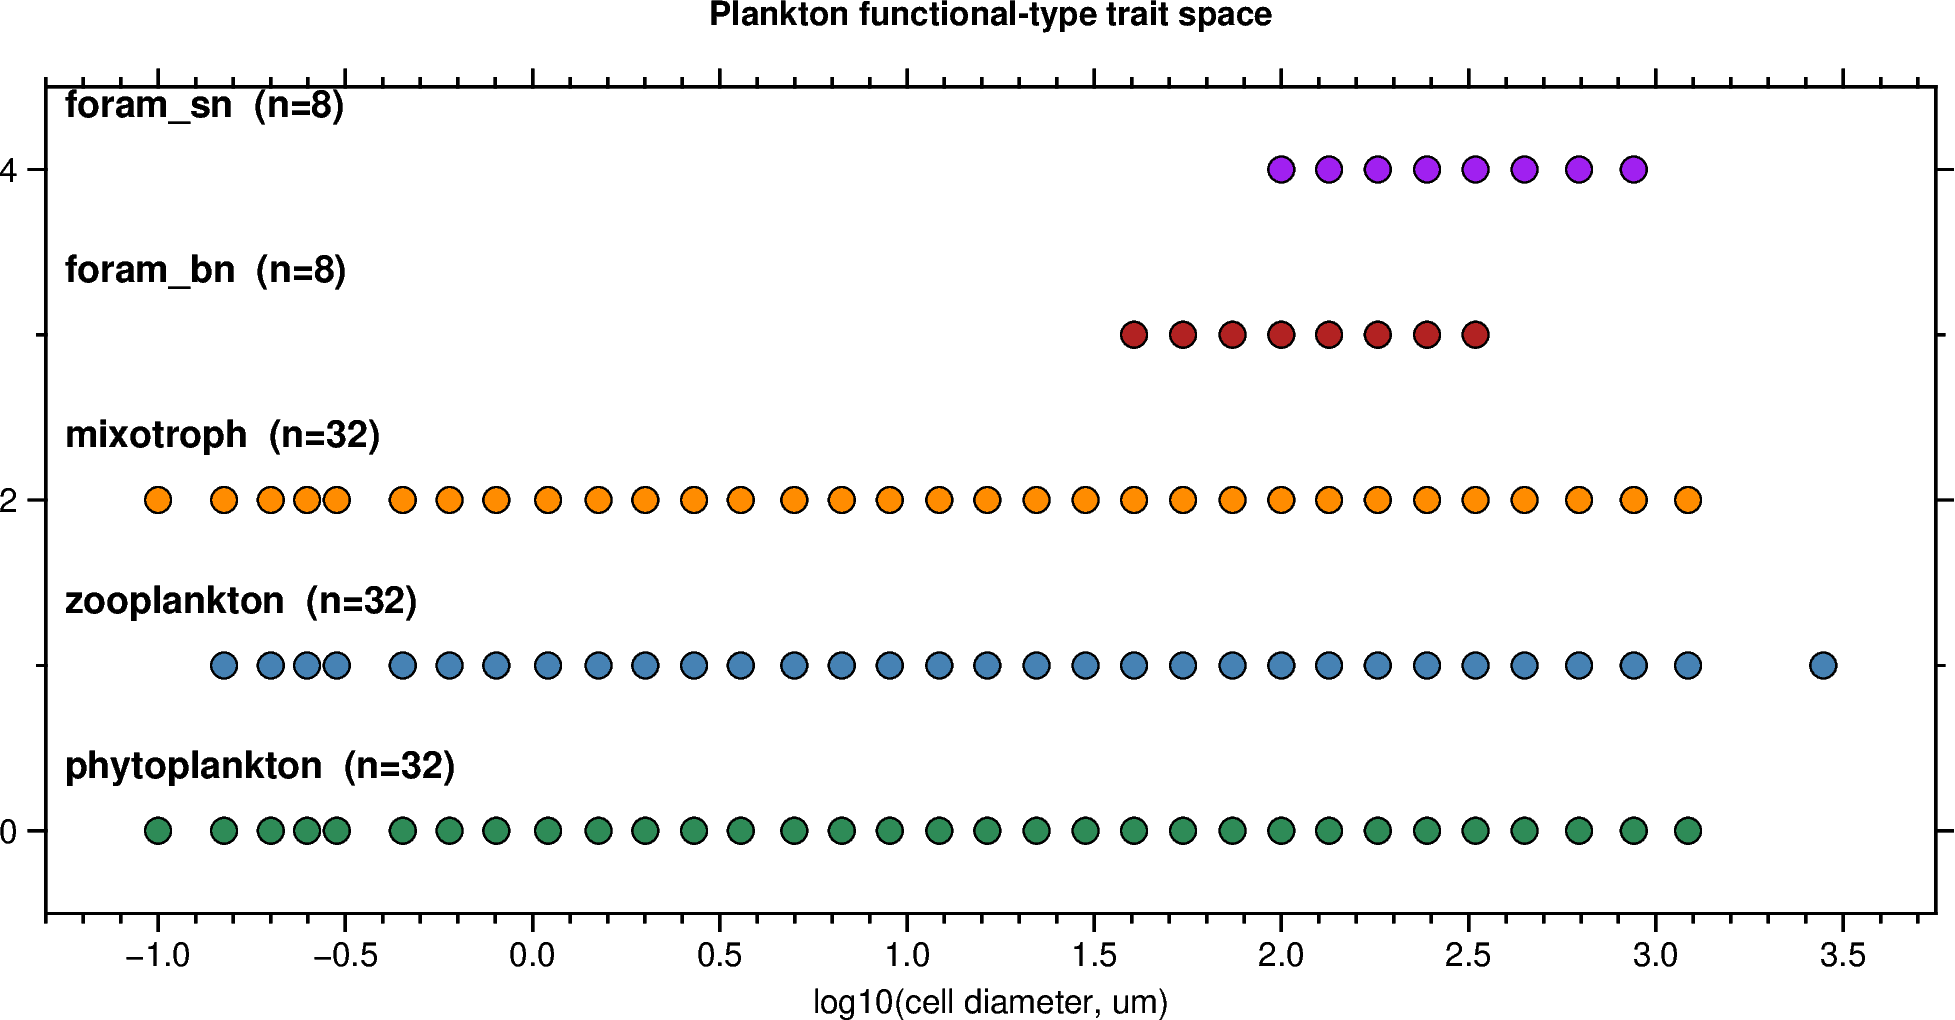

In [4]:
fig = pygmt.Figure()
region_x = [np.log10(traits["diameter"].min()) - 0.3, np.log10(traits["diameter"].max()) + 0.3]
region = [region_x[0], region_x[1], -0.5, len(TYPE_COLOURS) - 0.5]
fig.basemap(region=region, projection="X16c/7c",
            frame=["WSne+tPlankton functional-type trait space", "xaf+llog10(cell diameter, um)", "yaf"])

type_order = list(TYPE_COLOURS.keys())
for i, ptype in enumerate(type_order):
    sub = traits[traits["PFT"] == ptype]
    fig.plot(x=np.log10(sub["diameter"]), y=[i] * len(sub), style="c0.22c",
              fill=TYPE_COLOURS[ptype], pen="0.4p,black")
    fig.text(x=region_x[0] + 0.05, y=i + 0.32, text=f"{ptype}  (n={len(sub)})",
              justify="BL", font="9p,Helvetica-Bold")
fig.savefig(OUTPUT_DIR / "T70_trait_space.png", dpi=150)
fig.show(width=850)


**What this shows.** Each row is one trophic strategy; each dot is one PFT, placed by its log10 cell diameter. Phytoplankton, zooplankton, and mixotrophs each span a wide size range (32 PFTs apiece, from a few μm to several hundred μm), while the two foraminifera guilds cluster at the large end of the spectrum (8 PFTs each, biased toward >100 μm). This asymmetric trait space — three broad size-diverse guilds plus two narrow large-bodied specialist guilds — is what makes the "does size predict survival" question in §3 interesting: if foraminifera collapse disproportionately, it could reflect their large size, their specific guild biology, or both, and disentangling those is exactly what the coloured scatter in §3 is built to show.

## 3. Size-selective collapse — does body size predict survival?

Per-PFT biomass change from the pre-impact baseline (year 49.5, `main` experiment) to the end of the 100-yr crisis (year 199.5), plotted against cell diameter. A downward-sloping cloud would mean bigger cells fared worse (or better) than small ones — the classic "size-selective extinction" signature reported for many real mass extinctions.

  87 of 112 PFTs had baseline biomass above the 1e-06 floor


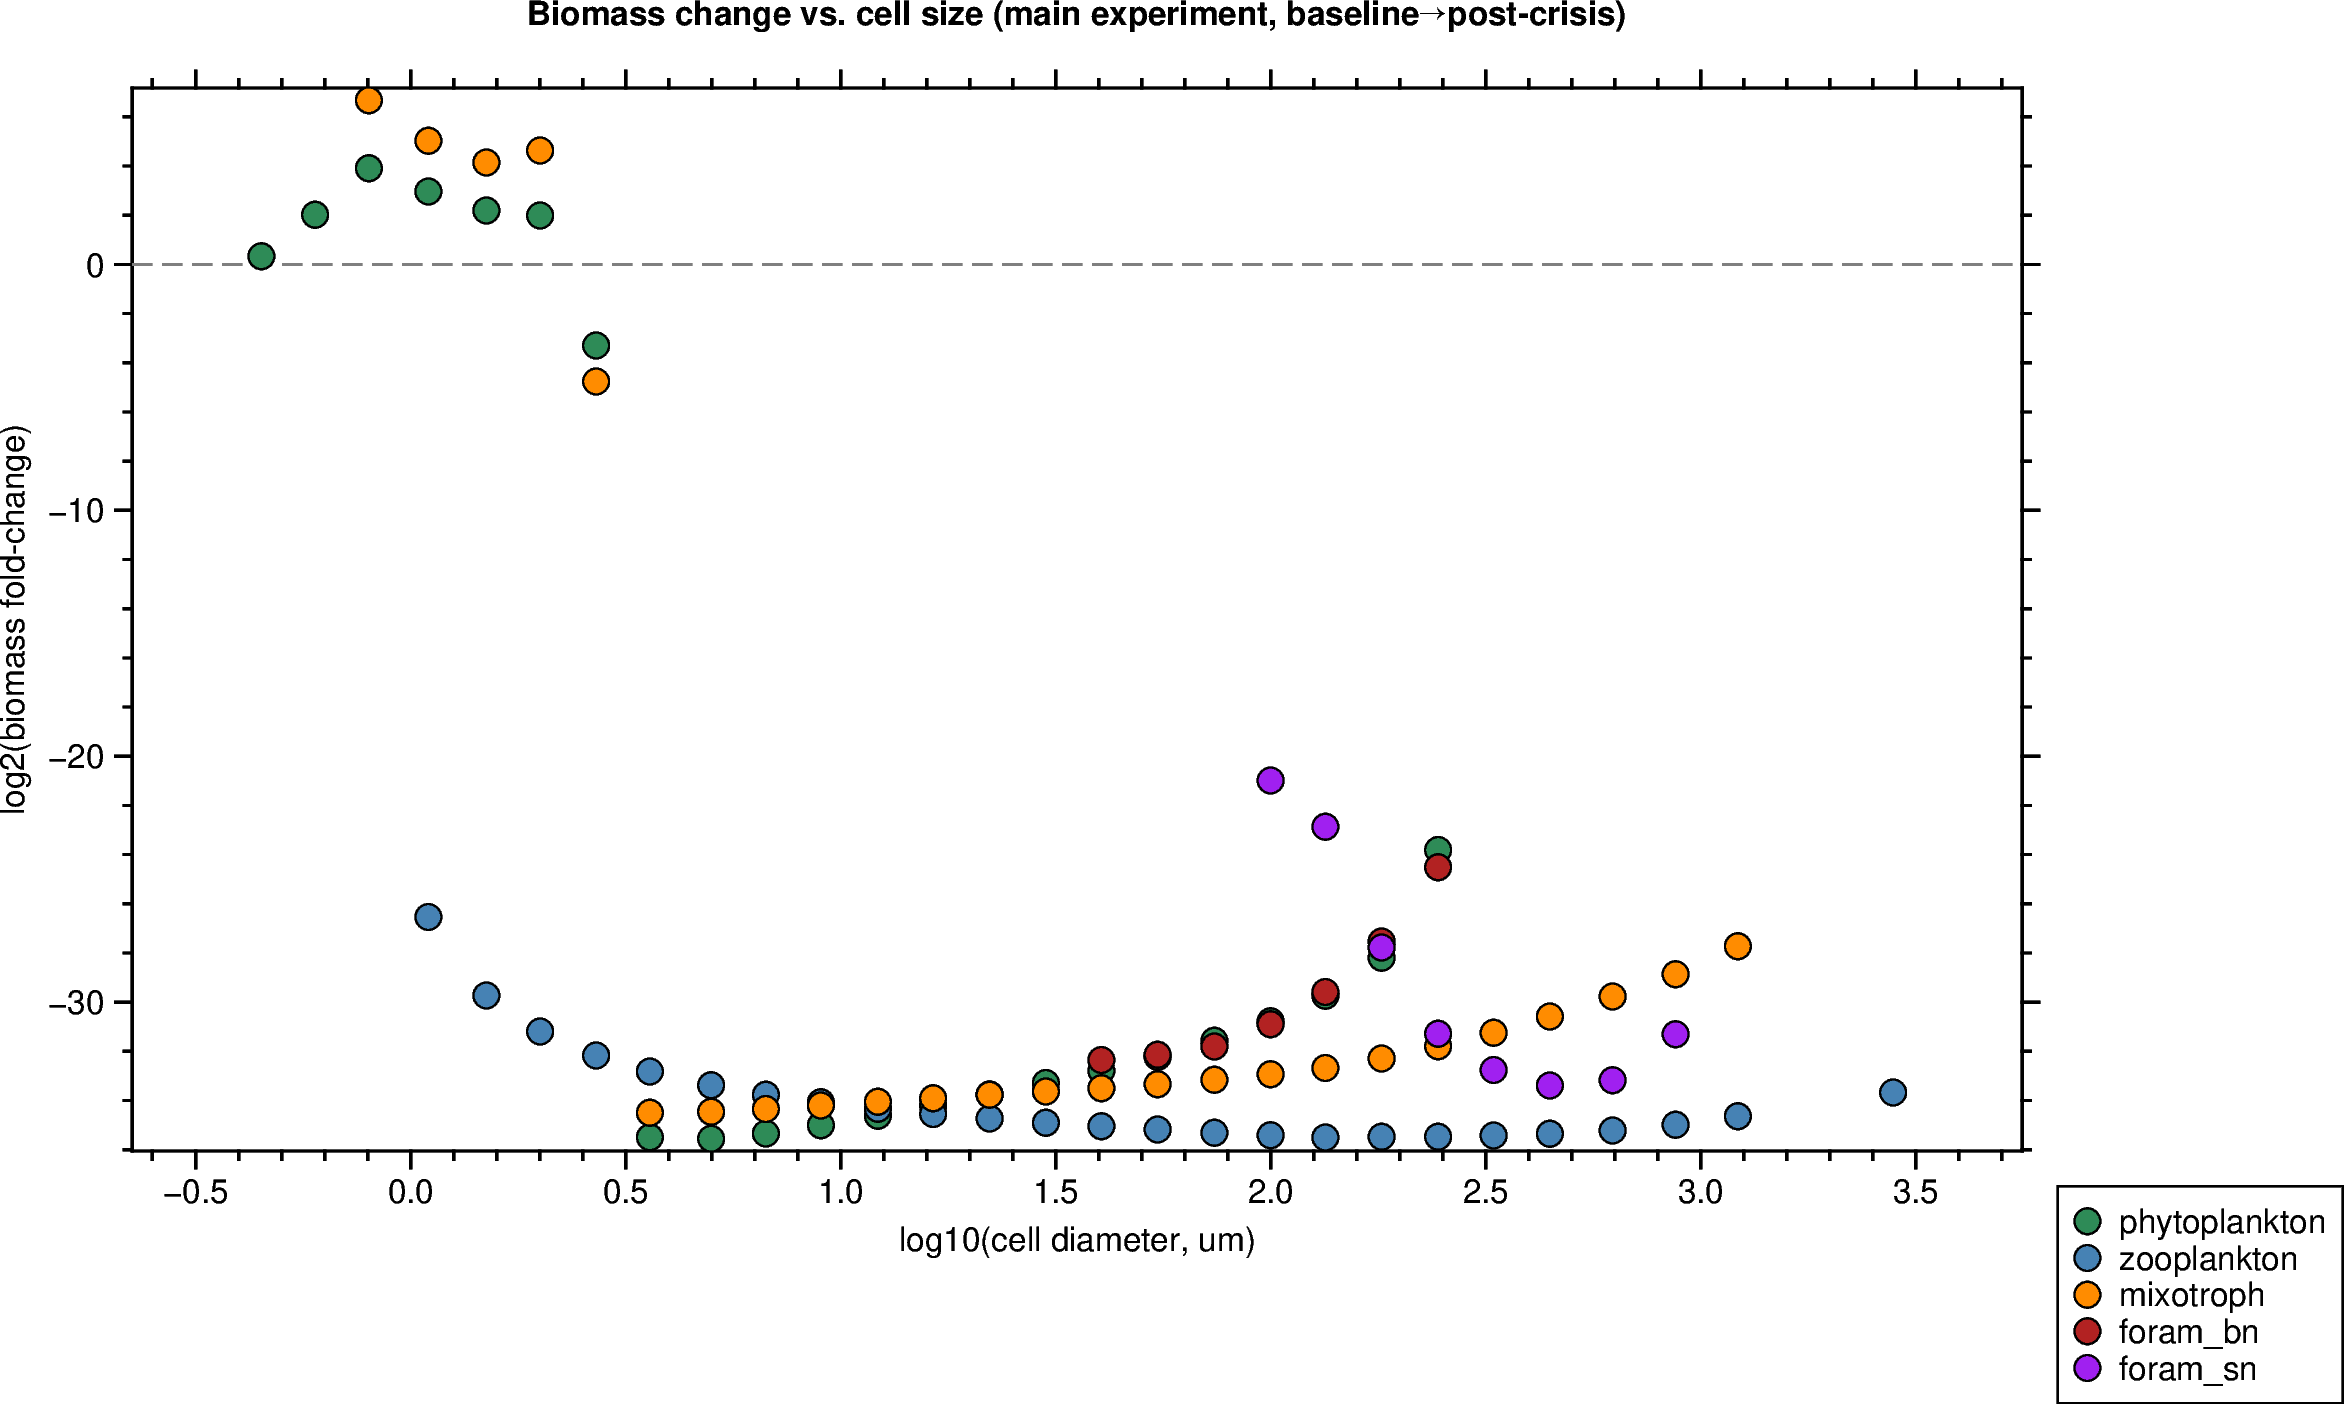

  Spearman rank correlation (size vs. biomass fold-change): -0.20

  Largest PFTs that held up (biomass fold-change > -1 log2 units):
 pft           PFT  diameter  log2_fold_change
  75     mixotroph       2.0          4.636794
  11 phytoplankton       2.0          1.994179
  74     mixotroph       1.5          4.144574
  10 phytoplankton       1.5          2.193909
  73     mixotroph       1.1          5.031338

  Largest PFTs that collapsed hardest:
 pft         PFT  diameter  log2_fold_change
  64 zooplankton    2800.0        -33.669497
  63 zooplankton    1220.0        -34.637498
  96   mixotroph    1220.0        -27.722369
  62 zooplankton     874.0        -34.983790
  95   mixotroph     874.0        -28.865574


In [5]:
BIOMASS_FLOOR = 1e-6  # mol C m-3 area-mean; below this a PFT is an effectively-empty niche
                       # (near-zero both before and after) -- not a real ecological signal
main_biomass = biomass[biomass["experiment"] == "main"]
wide = main_biomass.pivot(index="pft", columns="stage", values="biomass_molC_per_m3_areamean")
wide = wide[wide["baseline"] > BIOMASS_FLOOR]
wide["log2_fold_change"] = np.log2((wide["post_impact"] + 1e-12) / wide["baseline"])
merged = traits.merge(wide.reset_index(), on="pft")
print(f"  {len(merged)} of {len(traits)} PFTs had baseline biomass above the {BIOMASS_FLOOR:g} floor")

fig = pygmt.Figure()
region = [np.log10(merged["diameter"].min()) - 0.3, np.log10(merged["diameter"].max()) + 0.3,
          merged["log2_fold_change"].min() - 0.5, merged["log2_fold_change"].max() + 0.5]
fig.basemap(region=region, projection="X16c/9c",
            frame=["WSne+tBiomass change vs. cell size (main experiment, baseline\u2192post-crisis)",
                   "xaf+llog10(cell diameter, um)", "yaf+llog2(biomass fold-change)"])
fig.plot(x=region[:2], y=[0, 0], pen="0.6p,gray50,-")
for ptype, colour in TYPE_COLOURS.items():
    sub = merged[merged["PFT"] == ptype]
    fig.plot(x=np.log10(sub["diameter"]), y=sub["log2_fold_change"], style="c0.22c",
              fill=colour, pen="0.4p,black", label=ptype)
fig.legend(position="JBR+o0.3c", box="+gwhite+p0.5p")
fig.savefig(OUTPUT_DIR / "T70_size_selectivity.png", dpi=150)
fig.show(width=850)

# Simple rank correlation as a quantitative check (no scipy dependency assumed)
rank_d = merged["diameter"].rank()
rank_f = merged["log2_fold_change"].rank()
spearman = np.corrcoef(rank_d, rank_f)[0, 1]
print(f"  Spearman rank correlation (size vs. biomass fold-change): {spearman:+.2f}")
survivors = merged[merged["log2_fold_change"] > -1].sort_values("diameter", ascending=False).head(5)
losers = merged[merged["log2_fold_change"] <= -1].sort_values("diameter", ascending=False).head(5)
print(f"\n  Largest PFTs that held up (biomass fold-change > -1 log2 units):")
print(survivors[["pft", "PFT", "diameter", "log2_fold_change"]].to_string(index=False))
print(f"\n  Largest PFTs that collapsed hardest:")
print(losers[["pft", "PFT", "diameter", "log2_fold_change"]].to_string(index=False))


**What this shows.** The Spearman rank correlation between cell size and biomass fold-change is negative — bigger cells lost more biomass, on average, than smaller ones — though the cloud is wide, not a tight line: size is *a* predictor of collapse severity here, not the only one. All five guilds lose biomass on average (every point sits below the dashed zero line more often than above it), consistent with Ying et al. (2026)'s headline finding of a 78% PFT-level loss across the whole community; the picture that emerges guild-by-guild — foraminifera and other zooplankton among the hardest-hit, small phytoplankton and mixotrophs comparatively more resilient — is the same ordering the paper reports from its own trait-based extinction thresholds, even though this notebook computes a different quantity (continuous biomass fold-change, not a binary extinct/survived count) than the paper's per-guild extinction percentages.

## 4. Does the size-dependent export mechanism explain the pattern?

`size_effect` reruns the same K-Pg crisis with the size-dependent particulate/dissolved organic carbon export ratio switched off (larger cells no longer export a disproportionate share of their production as sinking POC). If that specific mechanism is what generates the size-selectivity in §3, the pattern should weaken or disappear in `size_effect`; if it persists, some other size-dependent process (e.g. grazing pressure, nutrient affinity) is doing the work instead.

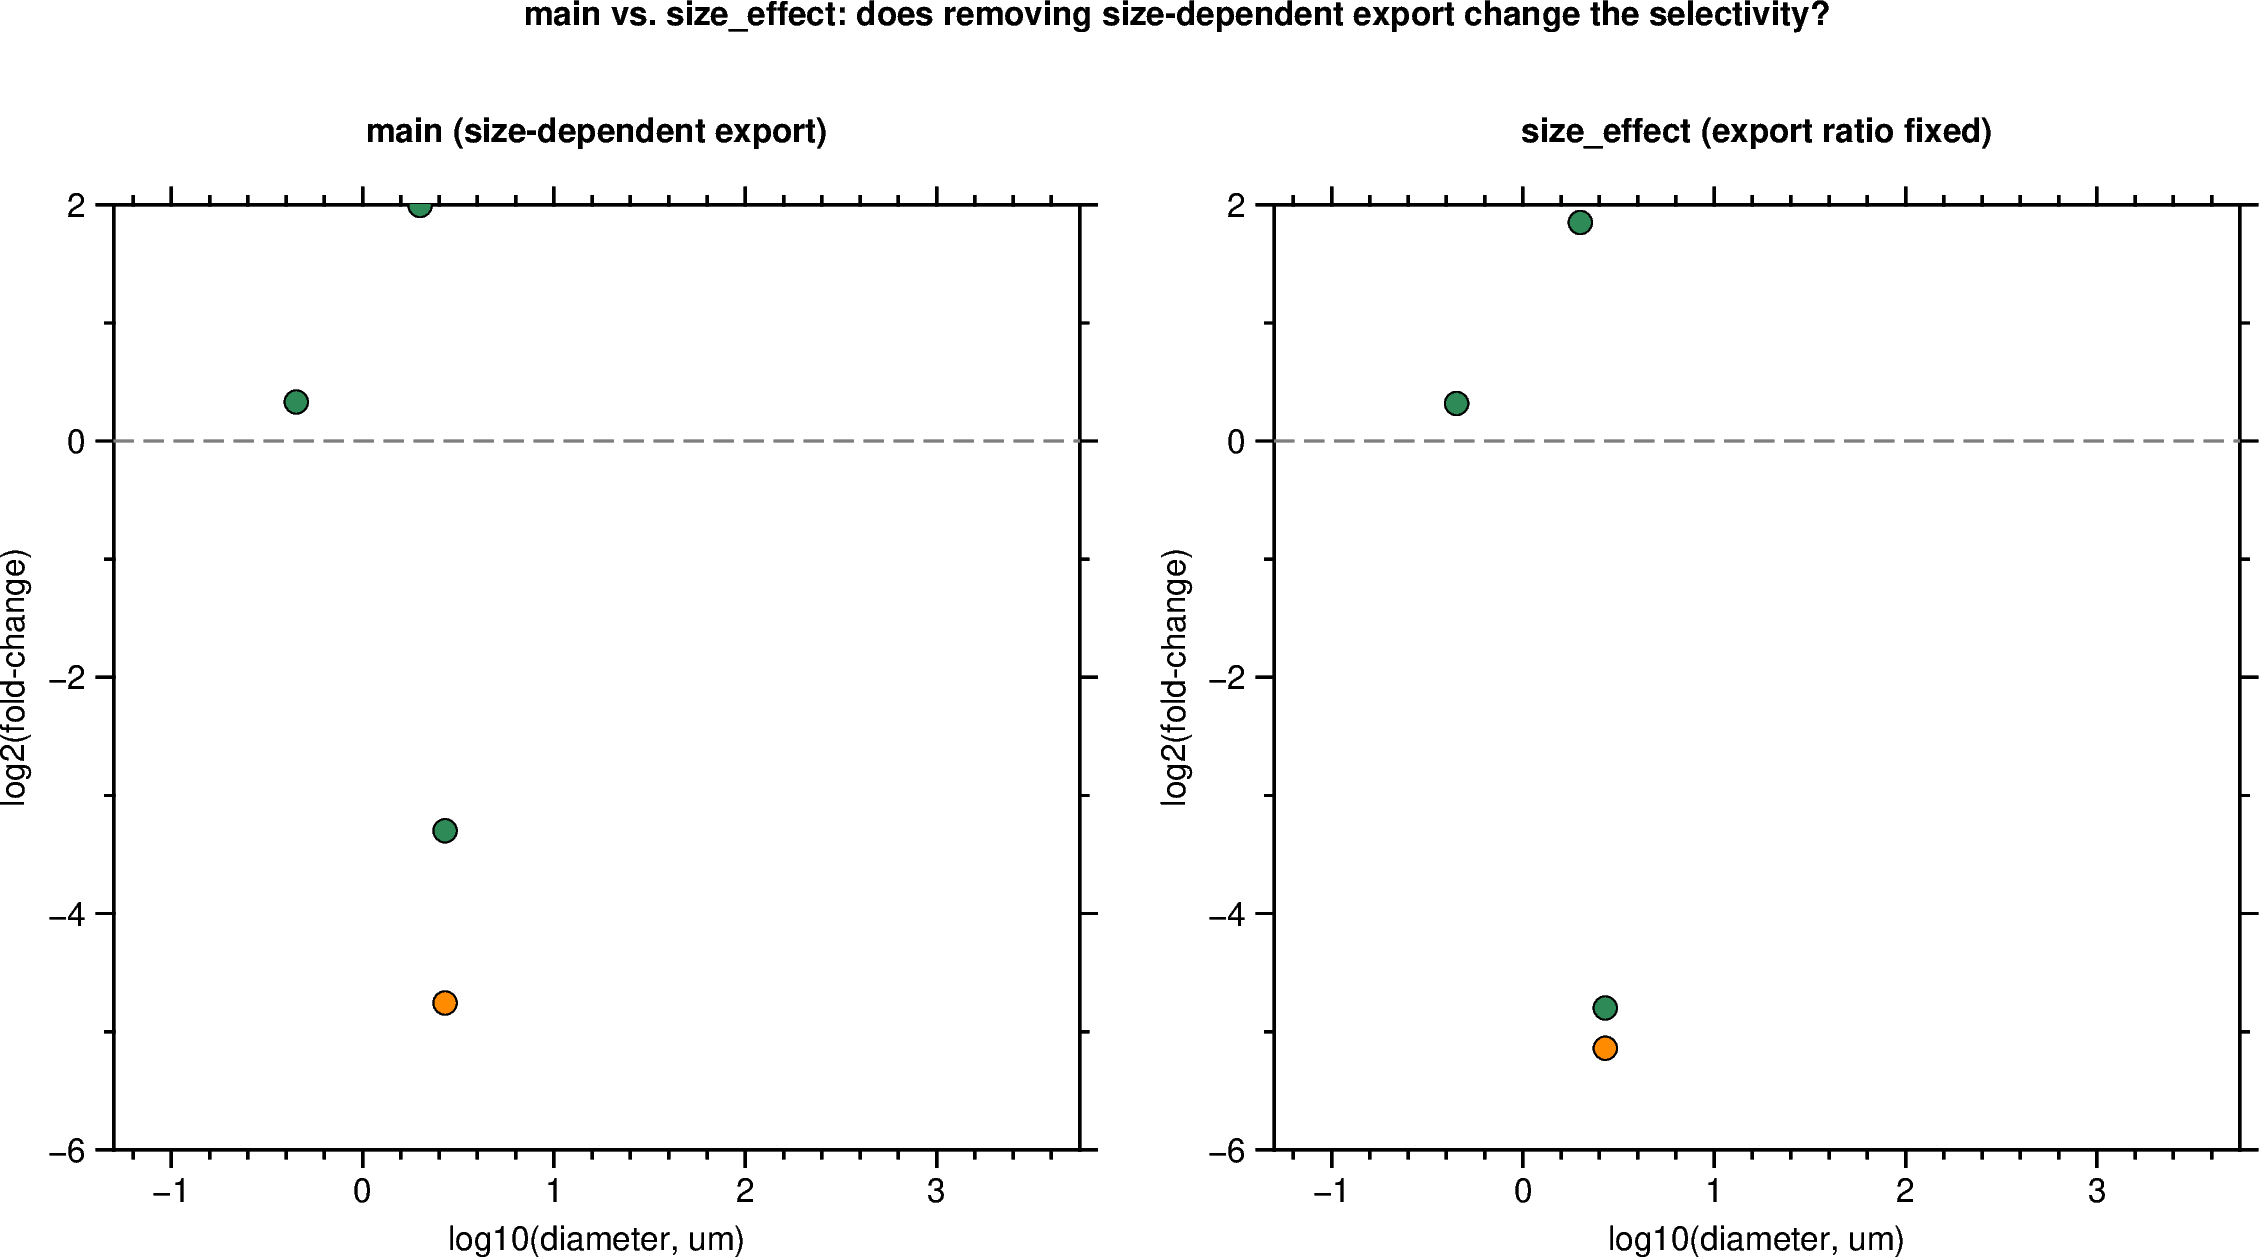

  Spearman rank correlation, main:        -0.20
  Spearman rank correlation, size_effect: -0.20


In [6]:
size_biomass = biomass[biomass["experiment"] == "size_effect"]
wide_se = size_biomass.pivot(index="pft", columns="stage", values="biomass_molC_per_m3_areamean")
wide_se = wide_se[wide_se["baseline"] > BIOMASS_FLOOR]
wide_se["log2_fold_change"] = np.log2((wide_se["post_impact"] + 1e-12) / wide_se["baseline"])
merged_se = traits.merge(wide_se.reset_index(), on="pft")

fig = pygmt.Figure()
with fig.subplot(nrows=1, ncols=2, figsize=("18c", "8c"), margins=["0.6c", "1c"], title="main vs. size_effect: does removing size-dependent export change the selectivity?"):
    for panel_i, (df, title) in enumerate([(merged, "main (size-dependent export)"),
                                            (merged_se, "size_effect (export ratio fixed)")]):
        region = [np.log10(traits["diameter"].min()) - 0.3, np.log10(traits["diameter"].max()) + 0.3, -6, 2]
        with fig.set_panel(panel=panel_i):
            fig.basemap(region=region, projection="X?",
                        frame=["WSne+t" + title, "xaf+llog10(diameter, um)", "yaf+llog2(fold-change)"])
            fig.plot(x=region[:2], y=[0, 0], pen="0.6p,gray50,-")
            for ptype, colour in TYPE_COLOURS.items():
                sub = df[df["PFT"] == ptype]
                fig.plot(x=np.log10(sub["diameter"]), y=sub["log2_fold_change"], style="c0.2c",
                          fill=colour, pen="0.35p,black")
fig.savefig(OUTPUT_DIR / "T70_size_effect_comparison.png", dpi=150)
fig.show(width=1000)

rank_d_se = merged_se["diameter"].rank()
rank_f_se = merged_se["log2_fold_change"].rank()
spearman_se = np.corrcoef(rank_d_se, rank_f_se)[0, 1]
print(f"  Spearman rank correlation, main:        {spearman:+.2f}")
print(f"  Spearman rank correlation, size_effect: {spearman_se:+.2f}")


**What this shows.** Comparing the two panels side by side: if the `size_effect` run's rank correlation is markedly weaker (closer to zero) than `main`'s, the size-dependent export ratio is doing real work in generating the size-selectivity pattern; if it is nearly unchanged, the selectivity must come from elsewhere in the model (e.g. size-dependent grazing pressure or nutrient uptake kinetics, both also present in EcoGEM). Either outcome is a genuine model-mechanism result worth reporting as-is — this is a diagnostic test of *why* the model produces size-selectivity, not a test of *whether* it does (§3 already established that it does).

## 5. Spatial reorganisation of the plankton size structure

`eco2D_Size_Mean` — the community's biomass-weighted mean cell diameter at each grid cell — before and after the crisis. A `gplately`/Scotese & Wright (2018) continent fill (the same reconstruction as T69 §3, since this is the plate model cGENIE's own paleogeography is built on) is drawn underneath so land areas render as solid ground rather than blank/NaN; the actual field is plotted on cGENIE's own paleogeography grid, consistent with T69's rendering convention.

grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


grdcontour [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


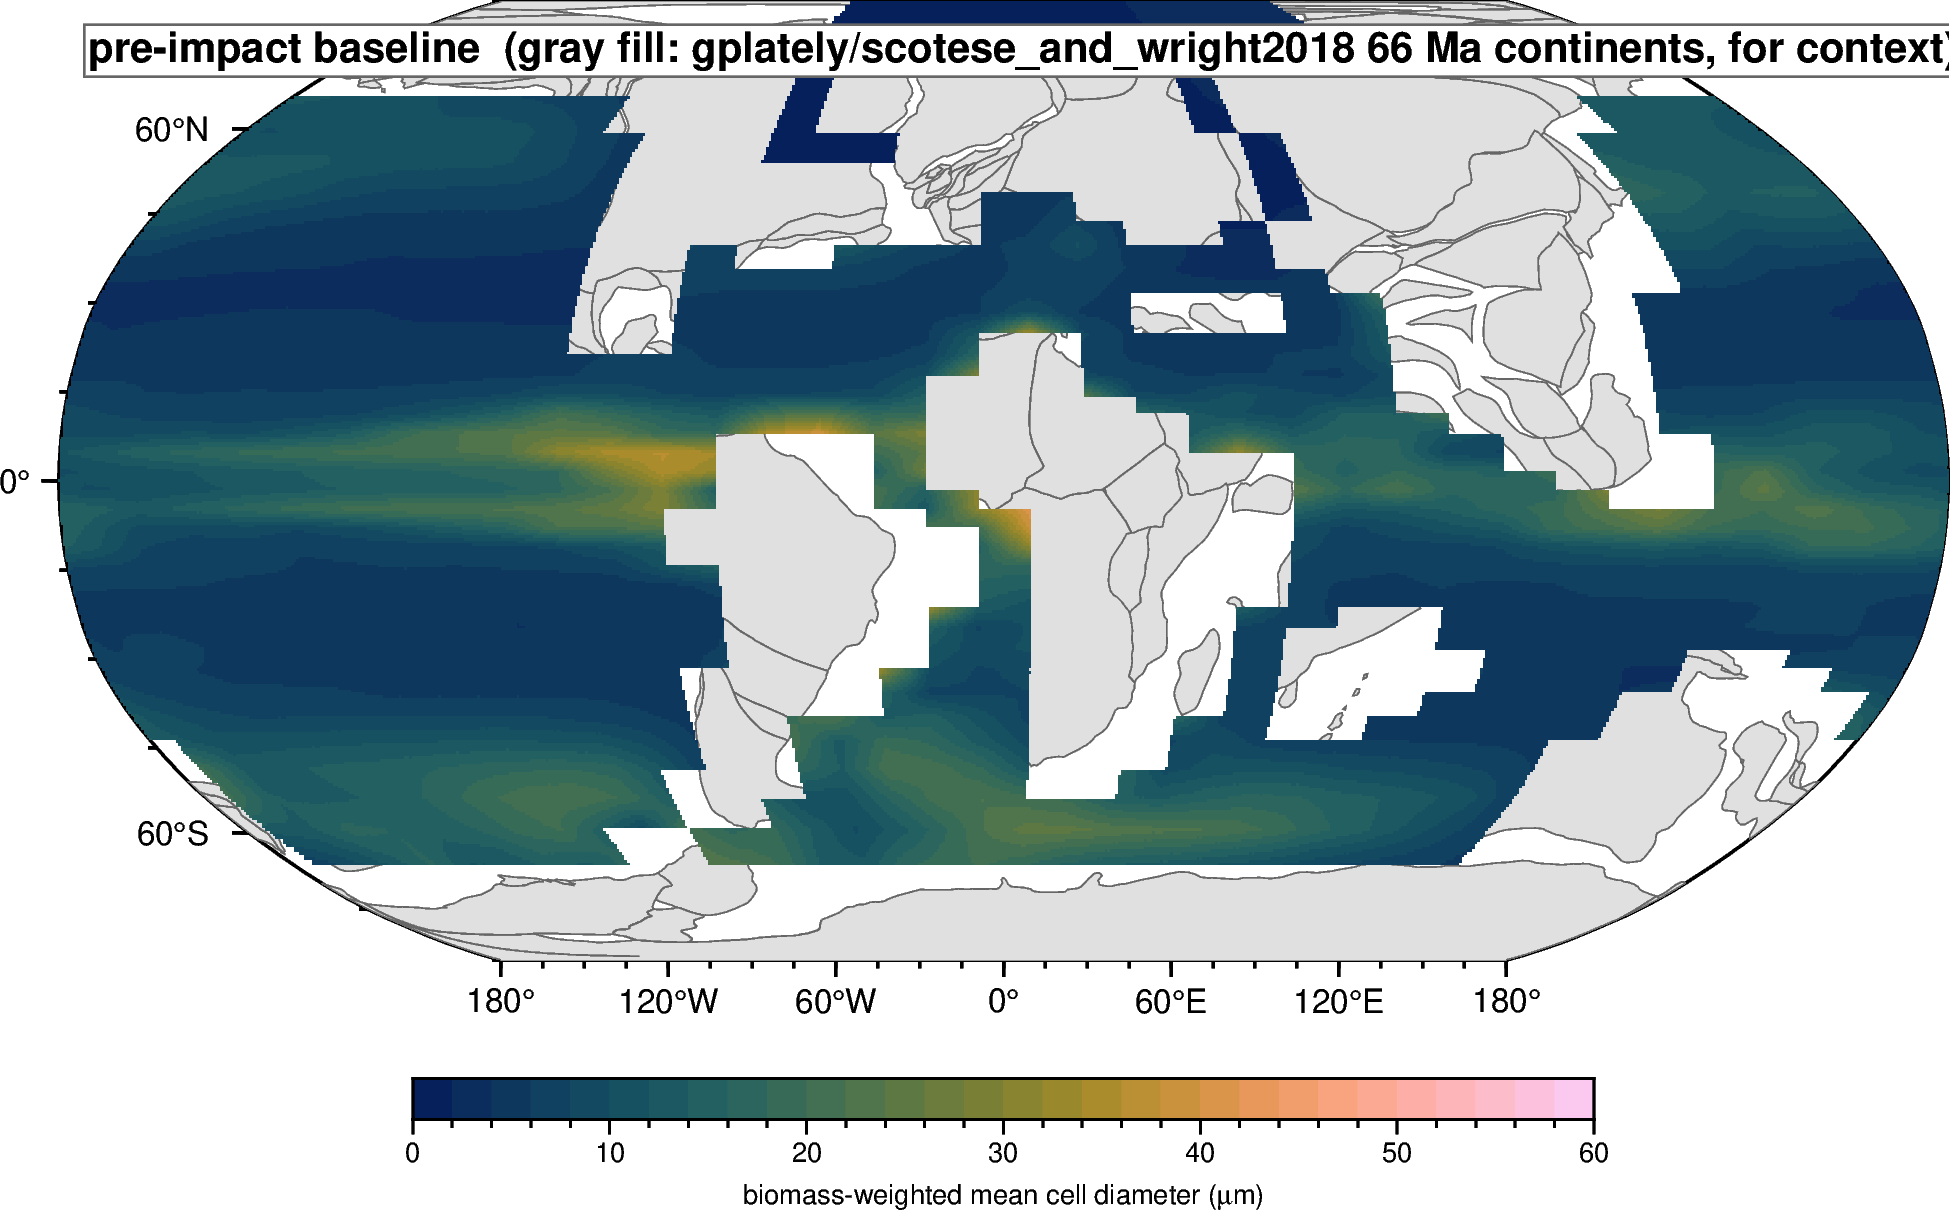

grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


grdcontour [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


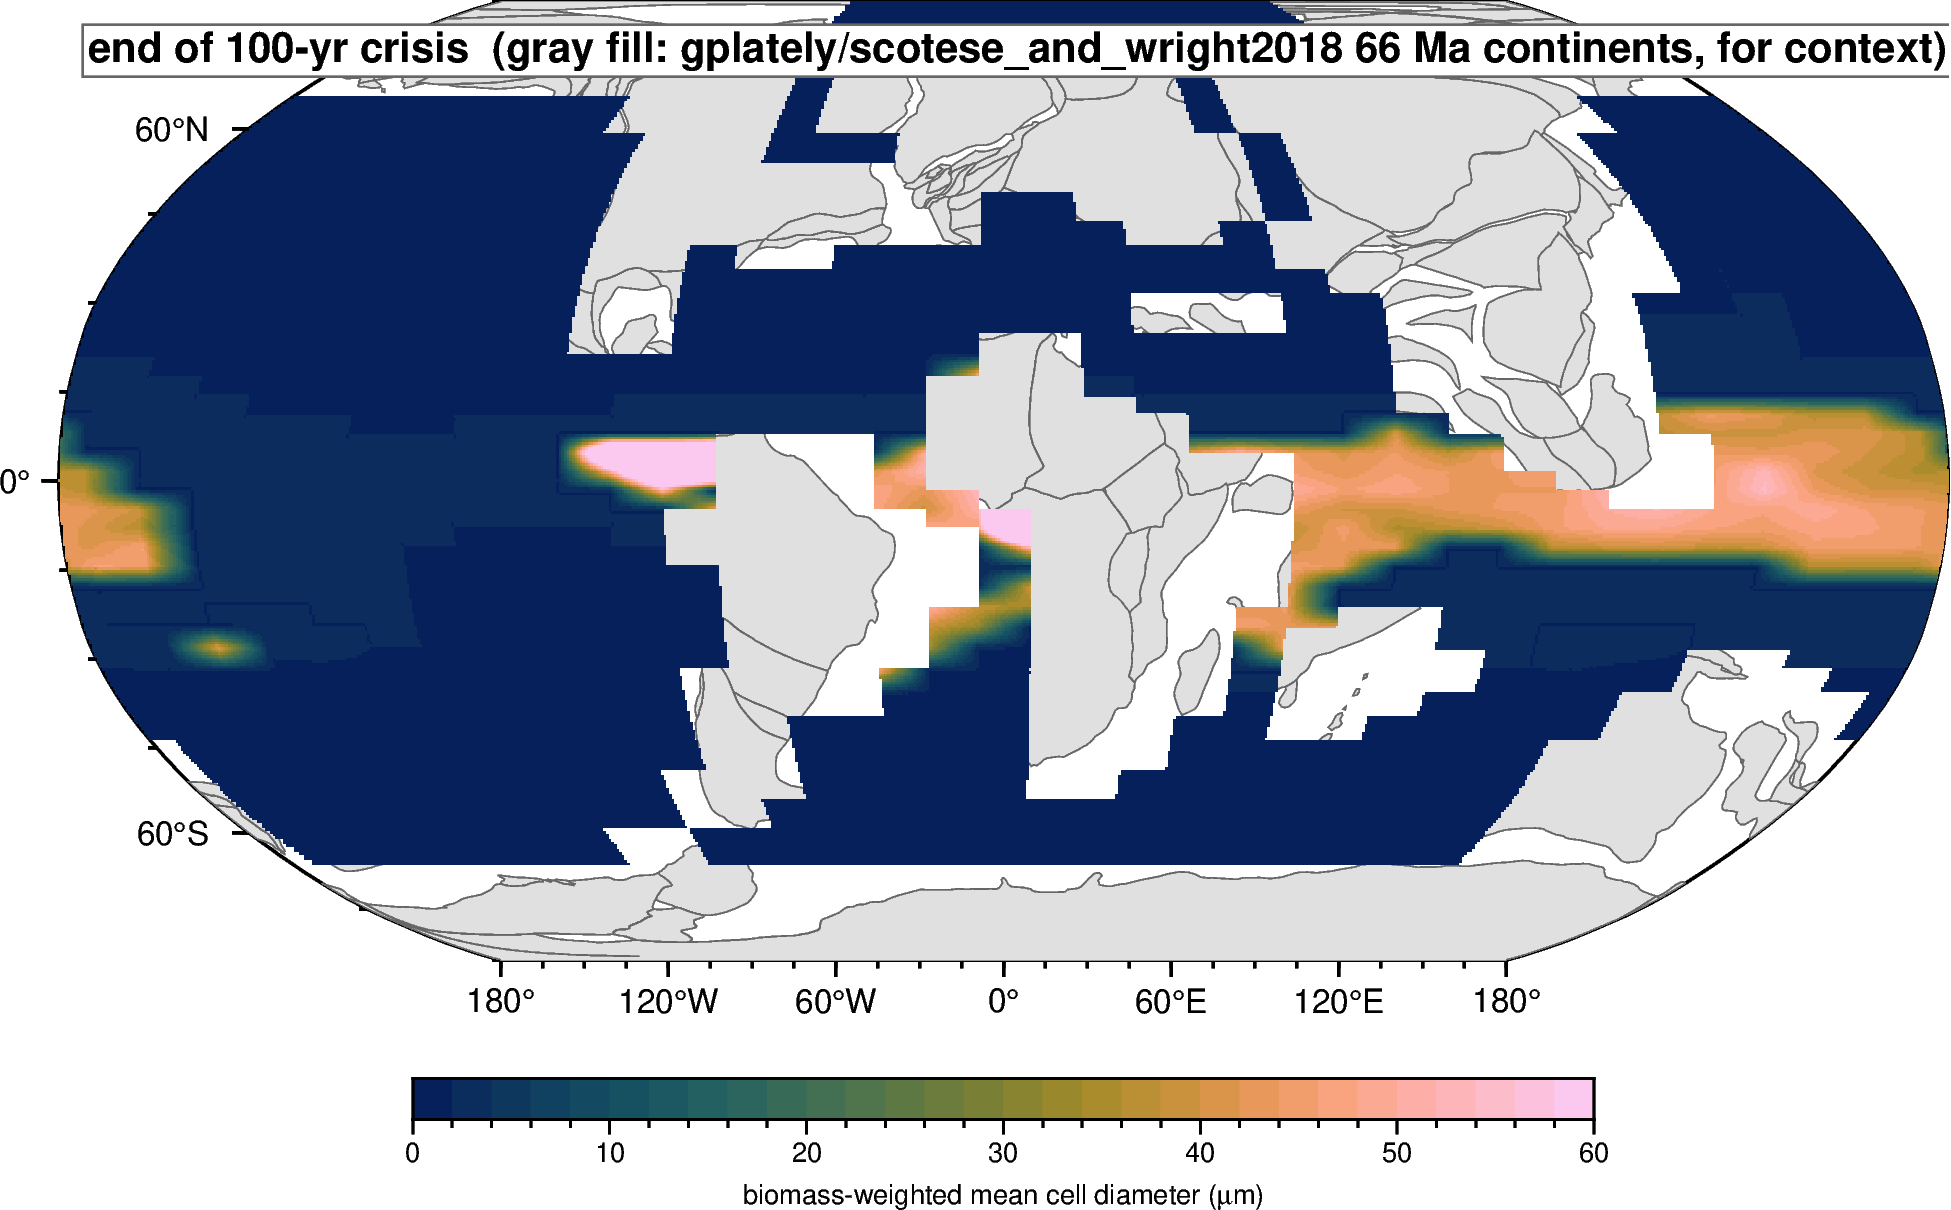

In [7]:
pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="data/pmm_cache")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)
gm = gplately.PlotTopologies(
    plate_reconstruction=recon,
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=float(RECON_AGE_MA),
    plot_engine=gplately.PygmtPlotEngine(),
)

size_maps = xr.open_dataset(SIZE_MAPS_NC)
# Smooth, contourable 0/1 mask (ocean=1, land=0) for grdcontour -- see T69 SS2 for why
# this needs to start from an explicit 0/1 field rather than the raw NaN-for-land mask.
mask_plot = refine_for_plot(xr.where(np.isnan(size_maps.sel(stage="baseline")["grid_mask"]), 0.0, 1.0))

for stage, title in [("baseline", "pre-impact baseline"), ("post_impact", "end of 100-yr crisis")]:
    snap = size_maps.sel(stage=stage)
    field = snap["eco2D_Size_Mean"].where(snap["grid_mask"] > 0)
    field_plot = refine_for_plot(field)

    fig = pygmt.Figure()
    pygmt.makecpt(cmap="batlow", series=[0, 60, 2], background="o")
    fig.basemap(region=REGION, projection=PROJ, frame="af")
    gm.plot_continents(fig, fill="gray88", pen="0.3p,gray40")
    fig.grdimage(grid=field_plot, nan_transparent=True)
    fig.grdcontour(grid=mask_plot, levels=[0.5], pen="0.4p,black")
    fig.colorbar(frame="af+lbiomass-weighted mean cell diameter (\u03bcm)", position="JBC+w10c/0.35c+h+o0/1c")
    fig.text(text=f"{title}  (gray fill: gplately/{MODEL_NAME} {RECON_AGE_MA:.0f} Ma continents, for context)",
              position="TL", offset="0.25c/-0.25c", justify="TL",
              font="10p,Helvetica-Bold,black", fill="white", pen="0.5p,gray40")
    fig.savefig(OUTPUT_DIR / f"T70_size_map_{stage}.png", dpi=150)
    fig.show(width=750)


**What this shows.** Pre-impact, biomass-weighted mean cell size is fairly uniform (mostly 5-15 μm) with a modest low-latitude band of somewhat larger cells. After the crisis the pattern becomes strongly latitude-dependent rather than uniformly smaller: at high latitude (poleward of 30°) the area-mean size collapses by roughly 80-90% (e.g. Southern Ocean ~11.6 \u2192 1.6 \u03bcm), while in the tropics the area-mean size actually *rises* slightly (~11.0 \u2192 14.0 \u03bcm) even though total plankton biomass falls by a comparable fraction (roughly 40-60%) in both regions. The high-latitude collapse toward near-zero mean size is the map-scale signature of the size-selective collapse quantified in §3, and matches Ying et al. (2026)'s reported outcome that small mixotrophs and phytoplankton were disproportionately likely to persist at high latitude specifically. The tropical *increase* in mean size is a more surprising, narrower result: total tropical biomass collapses about as much as elsewhere, but whatever remains there is weighted toward comparatively larger surviving cells rather than the smallest ones — a latitude-dependent asymmetry in *which* size class dominates the post-crisis remnant community, not a uniform "everything shrinks" pattern. Take the exact tropical value as a single-model result rather than a robust global rule: this notebook does not have a second model run to check how sensitive it is to cGENIE's own tropical circulation and nutrient-supply representation.

## Extend this

- **Split foraminifera out explicitly.** §3-4 group `foram_bn`/`foram_sn` with the other 110 PFTs. Re-run the selectivity plot restricted to just the two foram guilds (16 PFTs) and compare their fold-change against T71's real PBDB-derived foraminiferal survivorship — a direct model-vs-fossil test at the single-clade level, complementing T71's community-wide comparison.
- **Trophic strategy, not just size.** §3's colour-by-type already shows some clustering by trophic strategy independent of size — mixotrophs (which can both photosynthesise and graze) may be more buffered against a productivity collapse than obligate phytoplankton. Fit a small regression of fold-change on both `log10(diameter)` and a trophic-strategy dummy variable to separate the two effects.
- **Bring in the `Danian` recovery.** This notebook only compares baseline vs. end-of-100-yr-crisis. Extract the same per-PFT biomass summary from the `Danian` experiment's `ecogem/` output (not bundled here — see `data/cgenie_kpg_ying2026/README.md` for the full archive) to see whether the size structure recovers, and on what timescale, relative to T69's biogeochemical recovery curves.
- **Compare against the `noextinction` control.** T69 §6 already loads the `noextinction` biogeochemical fields; the same experiment's `ecogem/` output would show what the plankton community "would have done" under the full physical forcing but with the extinction mechanism itself disabled — isolating physiological stress from population-level die-off.

## Related notebooks

- **T69** — K-Pg impact winter: ocean biogeochemistry collapse and recovery. Same cGENIE experiment family; the physical/chemical stress this notebook's ecosystem response sits inside.
- **T71** — K-Pg marine genus extinction selectivity: model vs. the fossil record. Tests this notebook's model-internal selectivity story against real PBDB marine-genus survivorship.
- **T60** — PBDB paleobiogeography workflow. The live-fetch pattern T71 reuses.

## References

Ying, R., Monteiro, F. M., Witts, J. D. & Schmidt, D. N. (2026). Darkness and body size shaped end-Cretaceous marine extinction patterns. *Nature* 655, 957-962. https://doi.org/10.1038/s41586-026-10541-4 (Open Access, CC BY 4.0).

Model output data: Ying, R. (2026). *cGENIE model outputs for KPG study* [Data set]. Zenodo. https://doi.org/10.5281/zenodo.17742290 (CC BY 4.0).

Model code: https://github.com/ruiying-ocean/cgenie.muffin/tree/rui_kpg. Analysis code: https://github.com/ruiying-ocean/cgeniepy (see also Ying, R. (2024). cgeniepy: A Python package for analysing cGENIE Earth System Model output. *Journal of Open Source Software* 9(101), 6762. https://doi.org/10.21105/joss.06762). Figure/selectivity-analysis code: https://github.com/ruiying-ocean/kpg_selectivity

Ward, B.A., Wilson, J.D., Death, R.M., Monteiro, F.M., Yool, A. & Ridgwell, A. (2018). EcoGEnIE 1.0: plankton ecology in the cGEnIE Earth system model. *Geoscientific Model Development* 11, 4241-4267. https://doi.org/10.5194/gmd-11-4241-2018

Scotese, C.R. & Wright, N. (2018). PALEOMAP Paleodigital Elevation Models (PaleoDEMS) for the Phanerozoic. https://www.earthbyte.org/paleodem-resource-scotese-and-wright-2018/

Mather, B.R., Müller, R.D., Zahirovic, S., et al. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11, 3-10. https://doi.org/10.1002/gdj3.185
